In [2]:
import numpy as np
import torch
import crsData as crs
import matplotlib.pyplot as plt
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
    "font.size": 16,
})

colors = ['b','g','darkred','c','mediumpurple','sienna']

%matplotlib inline

In [3]:
import crossSections as cross
filename = './crs/BSR.txt'
BSR = cross.multipleCrossSections(filename)

filename = './crs/TRINITI.txt'
TRINITI = cross.multipleCrossSections(filename)

# datasets
datasets = ["Biagi","BSR","Hayashi","IST-Lisbon","Morgan","Phelps","Puech","TRINITI","SIGLO"]
Nsets = len(datasets)

In [4]:
refs = ['Chutjian1981','Buckman1983','Filipovic2000a','Filipovic2000b','Khakoo2004','Tsurubuchi1996','Schappe1994','Li1988','Rapp1965','Straub1995','Wetzel1987','Mielewska2004','Panajotovic1997','Gibson1996','Srivastava1981','TonThat1977']
Nrefs = len(refs)
swarms, idx = [], 0
for ref in refs:
#     if (ref=='Tsurubuchi1996'):
#         continue
    filename = '../crs-exp/%s.txt' % ref
    swarms.append( crs.crsData(filename) )
    print(swarms[idx].ref)
    print(swarms[idx].variables)
    for dataType, dataset in swarms[idx].datasets.items():
        print(crs.typeDictI2S[dataType])
        print(dataset.variables)
        print(dataset.data)
    idx += 1


Chutjian, A., & Cartwright, D. C. (1981). Electron-impact excitation of electronic states in argon at incident energies between 16 and 100 eV. Physical Review A, 23(5), 2178–2193. https://doi.org/10.1103/PhysRevA.23.2178
{'E': ['eV', 'n/a', 'n/a'], 'crs': ['cm2', 'n/a', 'n/a'], 'crs-rms': ['%', 'n/a', 'n/a']}
Excitation, level 1
['E', 'crs', 'crs-rms']
[[1.6000e+01 4.1900e-22 1.2151e-22]
 [2.0000e+01 3.1900e-22 9.2510e-23]
 [3.0000e+01 1.6600e-22 4.8140e-23]
 [5.0000e+01 3.6100e-23 1.1913e-23]
 [1.0000e+02 5.6000e-24 2.6320e-24]]
Excitation, level 2
['E', 'crs', 'crs-rms']
[[1.6000e+01 3.9700e-22 1.1513e-22]
 [2.0000e+01 3.7000e-22 1.0730e-22]
 [3.0000e+01 4.5600e-22 1.3224e-22]
 [5.0000e+01 5.7800e-22 1.6762e-22]
 [1.0000e+02 3.2800e-22 9.5120e-23]]
Excitation, level 3
['E', 'crs', 'crs-rms']
[[1.6000e+01 6.0900e-23 2.0097e-23]
 [2.0000e+01 6.4400e-23 2.1252e-23]
 [3.0000e+01 4.5400e-23 2.1338e-23]
 [5.0000e+01 1.1200e-23 5.2640e-24]
 [1.0000e+02 5.4100e-24 2.5427e-24]]
Excitation, le

## Ionization

Rapp, D., & Englander-Golden, P. (1965). Total cross sections for lonization and attachment in gases by electron impact. I. Positive ionization. The Journal of Chemical Physics, 43(5), 1464–1479. https://doi.org/10.1063/1.1696957
True
1000.0
Straub, H. C., Renault, P., Lindsay, B. G., Smith, K. A., & Stebbings, R. F. (1995). Absolute partial and total cross sections for electron-impact ionization of argon from threshold to 1000 eV. Physical Review A, 52(2), 1115–1124. https://doi.org/10.1103/PhysRevA.52.1115
True
20.0
Straub, H. C., Renault, P., Lindsay, B. G., Smith, K. A., & Stebbings, R. F. (1995). Absolute partial and total cross sections for electron-impact ionization of argon from threshold to 1000 eV. Physical Review A, 52(2), 1115–1124. https://doi.org/10.1103/PhysRevA.52.1115
True
20.0
Wetzel, R. C., Baiocchi, F. A., Hayes, T. R., & Freund, R. S. (1987). Absolute cross sections for electron-impact ionization of the rare-gas atoms by the fast-neutral-beam method. Physical Revie

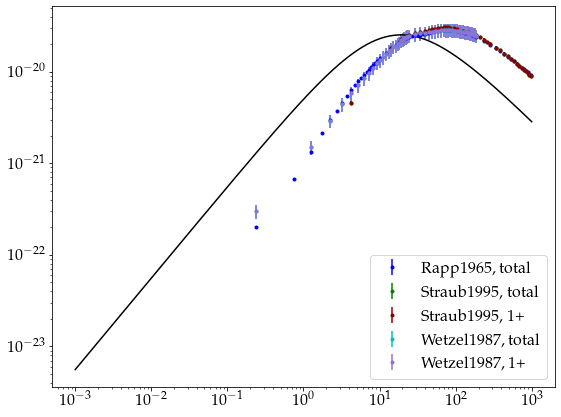

<Figure size 432x288 with 0 Axes>

In [11]:
from models import *
level = 1
dataType1 = crs.typeDictS2I['Ionization, '+str(level)+'+']
dataType = crs.typeDictS2I['Ionization, total']
threshold = np.floor(10*E_ion[level-1])/10.0


targetrefs = []

W = []
for k, swarm in enumerate(swarms):
    if dataType in swarm.datasets:
        targetrefs += [refs[k]+', total']
        print(swarm.ref)
        print(swarm.datasets[dataType].error_provided)
        temp = np.copy(swarm.datasets[dataType].data)
        print(temp[0,0])
        W += [temp]
        
        filename = '%s.ion.total.txt' % (refs[k])
        np.savetxt(filename, temp)
    if dataType1 in swarm.datasets:
        targetrefs += [refs[k]+', 1+']
        print(swarm.ref)
        print(swarm.datasets[dataType].error_provided)
        temp = np.copy(swarm.datasets[dataType].data)
        print(temp[0,0])
        W += [temp]
        
        filename = '%s.ion.1+.txt' % (refs[k])
        np.savetxt(filename, temp)
        
# # Include BSR dataset, except the first entry (excitation level).
# for c in BSR.crs:
#     if ((c.colType==2) and (c.deltaE>threshold) and (c.deltaE<threshold+0.1)):
#         targetrefs += ['BSR']
# #         mask = c.data[:,0]>2.5e-1+E_ext[level-1]
# #         temp = np.copy(c.data[mask,:])
#         temp = np.copy(c.data[1:,:])
#         error = temp[:,1][...,None] * 0.2
#         temp = np.append( temp, error, axis=1)
#         print(c.deltaE)
#         print(np.count_nonzero(np.logical_and((temp[:,0]-E_ext[level-1]>np.exp(1)), (temp[:,0]-E_ext[level-1]<np.exp(3)))))
#         W += [temp]

# mask = W[:,0] - E_ext[3] < 15.0
# W = W[mask,:]
# W = [W[-3]]
    
theta_ref = np.array([1.0, 1.0, 1.0])
Etest = np.linspace(-3.,3.,200)
Etest = 10.0 ** Etest + E_ion[level-1]
model0 = total_Ion_BED(theta_ref,Etest)
mask = model0 > 1.0e-25
Etest = Etest[mask]
model0 = model0[mask]

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
    "font.size": 16,
})

plt.figure(1)
for k, Wk in enumerate(W):
#     if(k>2): continue
    plt.errorbar(Wk[:,0]-E_ion[level-1],Wk[:,1],yerr=Wk[:,2],fmt='.',color=colors[k],label=targetrefs[k])
plt.plot(Etest-E_ion[level-1],model0,'-k')
plt.xscale('log')
plt.yscale('log')

# h = []
# for k, dataset in enumerate(datasets[:-2]):
#     if ((dataset=="Phelps") or (dataset=="Morgan")): continue
#     filename = "./crs/%s.txt" % dataset
#     tmp = cross.multipleCrossSections(filename)

#     for c in tmp.crs:
#         if ((c.colType==2) and (c.deltaE<11.6)):
# #         if ((c.colType==2) and (c.deltaE>11.8) and (c.deltaE<11.9)):
#             targetmf = np.copy(c.data[1:,:])
#             plt.loglog(targetmf[:,0] - E_ext[level-1],targetmf[:,1],'-')
#             h += [dataset]
# plt.title('Excitation 11.55eV')
plt.legend(loc="lower right")
fig = plt.gcf()
fig.set_size_inches(9, 7)
plt.show()
# fig.savefig("./dataset1.pdf", dpi=600)
plt.savefig('./ionization.png',dpi=1200)


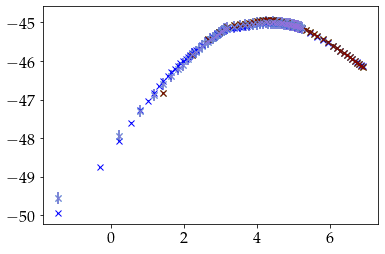

In [119]:
Wlog = []
for Wk in W:
    temp = np.copy(Wk)
    temp[:,0] = np.log(temp[:,0] - E_ion[level-1])
    temp[:,2] = np.log(1.0 + temp[:,2] / temp[:,1])
    temp[:,1] = np.log(temp[:,1])
    Wlog += [temp]

        
plt.figure(1)
for k, wlogk in enumerate(Wlog):
#     if((k>2)): continue
    plt.errorbar(wlogk[:,0],wlogk[:,1],yerr=wlogk[:,2],fmt='x',color=colors[k])
    
xd, yd, ed = [], [], []
xm = []
for wlogk in Wlog:
    temp = wlogk[:,0][:,None].repeat(len(wlogk),1)
    xd += [temp - temp.transpose()]
#     xm += [0.5*temp + 0.5*temp.t()]
    xm += [wlogk[:,0]]
    
    yd += [wlogk[:,1]]
    ed += [wlogk[:,2]]        

In [102]:
from torch_kernel import *
# cov_kern = ExpKernelPack(1,requires_grad=False)
cov_kern = MaternPack(1,requires_grad=False)
print(cov_kern.var[0].dtype, cov_kern.scale[0].dtype)

from models import *

def log_prior(theta):
    lp = 0.0
#     if ((theta[0]<=0.0) or (theta[1]<0.0)):
#         return - np.inf
    if ((theta[-2]<=1.0e-2) or (theta[-1]<=1.0e-3) or (theta[-2]>=1e1) or (theta[-1]>=1e1)):
        return - np.inf
#     theta_ref = np.array([10.4e0, 2.0])
#     sigma2 = ( 1.0 * theta_ref )**2
#     sigma2[0] *= 0.5
#     lp = - 0.5 * np.sum( (theta[:2] - theta_ref)**2 / sigma2 + np.log(2.0*np.pi*sigma2) )
#     lp += - np.log(theta[-1]) - np.log(np.log(1e1) - np.log(1e-3))
    lp += - np.log(theta[-2]) - np.log(np.log(1e1) - np.log(1e-2))
        
    return lp


def log_likelihood(theta):
    # compute log-normal probability
    cov_kern.var[0], cov_kern.scale[0] = theta[-2:]
    
    lk = 0.0
    for k in range(len(Wlog)):
        cov = cov_kern.forward(0,torch.tensor(xd[k]))
        cov += torch.diag(torch.tensor(ed[k]**2))
        try:
            LKb = torch.linalg.cholesky(cov)
        except RuntimeError:
            return - np.inf
            
        logModel = np.log( total_Ion_BED(theta[:3],W[k][:,0]) )
        dev = logModel - yd[k]
        dev = torch.tensor(dev)
        cov_inv_y = torch.cholesky_solve(dev.reshape(dev.size(0),1),LKb).reshape(-1)
        temp = - 0.5 * torch.dot(dev,cov_inv_y) - torch.sum(torch.log(torch.diagonal(LKb))) - 0.5 * xm[k].size * np.log(2.0*np.pi)
        lk += temp.detach().numpy()
    return lk

def log_posterior(theta):
    lp = log_prior(theta)
    lk = log_likelihood(theta)
    if (not np.isfinite(lp)) or (not np.isfinite(lk)):
        return - np.inf
    return lp + lk

torch.float64 torch.float64


In [103]:
import emcee
nwalkers = 32
theta_ref = np.array([1.0,1.0,1.0,1.0,0.1])
ndim = len(theta_ref)
pos = theta_ref * (1.0 + 0.1 * np.random.randn(nwalkers,ndim) )
# pos[:16,0] *= 3.0
# pos[:,-1] = 1.0 * np.random.randn(nwalkers)

sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_posterior
)

In [106]:
# sampler.run_mcmc(pos, 1);

for k in range(10):
    sampler.run_mcmc(None, 500, progress=True);
    tau = sampler.get_autocorr_time(tol=0)
    print(tau)

100%|████████████████████████████████████████████████████| 500/500 [00:07<00:00, 65.11it/s]


[135.07352092  72.6238789   85.32660215 221.79642869 282.08436807]


100%|████████████████████████████████████████████████████| 500/500 [00:07<00:00, 66.02it/s]


[135.19721426  72.66567091  85.39857243 222.07324564 281.39752171]


100%|████████████████████████████████████████████████████| 500/500 [00:07<00:00, 65.47it/s]


...

[135.74166622  72.89174199  85.75624785 223.27956946 277.19981729]


100%|████████████████████████████████████████████████████| 500/500 [00:07<00:00, 63.82it/s]


[135.81531384  72.90042278  85.77090836 223.41597672 276.23663357]


100%|████████████████████████████████████████████████████| 500/500 [00:07<00:00, 66.08it/s]


[135.88005529  72.90564584  85.78207635 223.54734976 276.31128955]


(12832, 5)


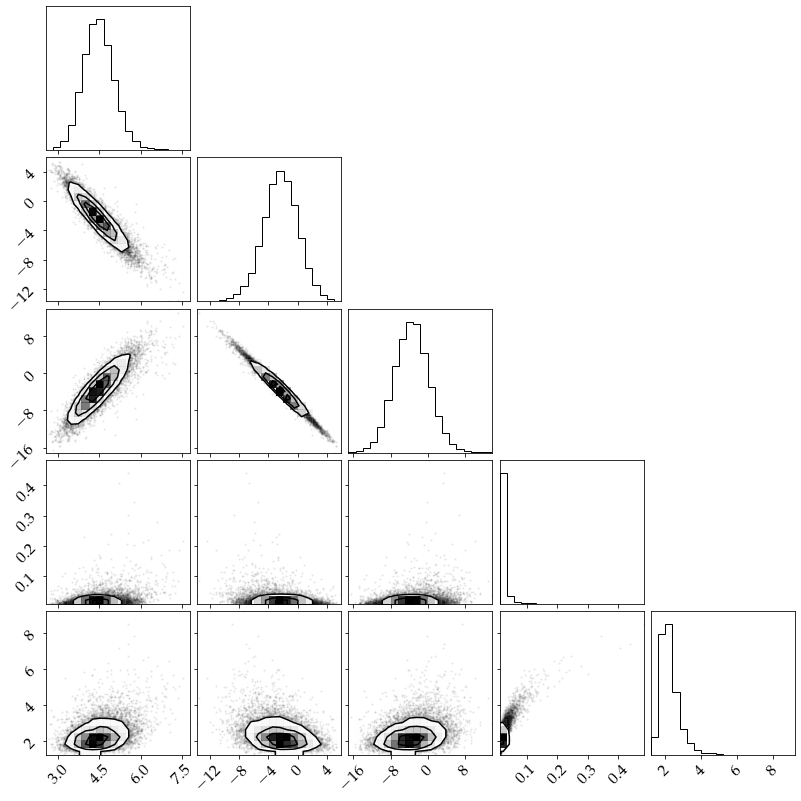

In [114]:
flat_samples = sampler.get_chain(discard=2*int(max(tau)), thin=int(0.5*min(tau)), flat=True)
# flat_samples = sampler.get_chain(discard=200, thin=50, flat=True)
# flat_samples = sampler.get_chain(flat=True)
# mask = flat_samples[:,0]>0.0
# flat_samples = flat_samples[mask,:]
print(flat_samples.shape)

tmp = flat_samples
tmp.tofile('../crs-Bayes-gpr/without-swarm/crs.ionization.total.dat')

import corner

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
    "font.size": 16,
})

fig = corner.corner(flat_samples);
fig.savefig("./ionization.total.corner.pdf", dpi=1200)

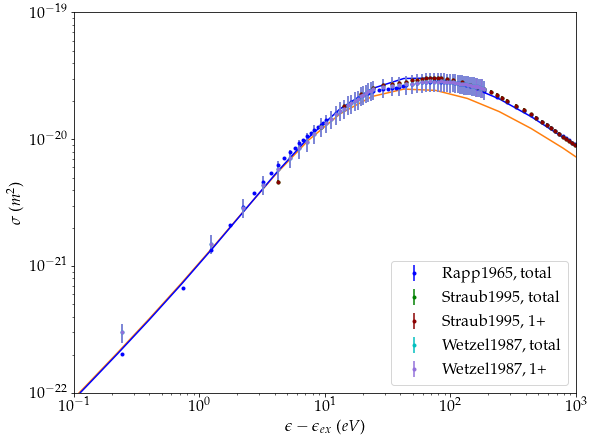

In [14]:
flat_samples = np.fromfile('../crs-Bayes-gpr/without-swarm/crs.ionization.total.dat')
flat_samples = np.reshape(flat_samples, [int(len(flat_samples)/5), 5])
sample_mean = np.mean(flat_samples, axis=0)

Nw = 25
wtest = np.linspace(-5,9.,Nw)
Etest = np.exp(wtest) + E_ion[level-1]

inds = np.random.randint(len(flat_samples), size=1)
for ind in inds:
    sample = flat_samples[ind]
    models = total_Ion_BED(sample[:3],Etest)
    mask = models > 1.0e-25
    plt.plot(Etest[mask]-E_ion[level-1], models[mask], "C1", alpha=1)
mean_model = total_Ion_BED(sample_mean[:3], Etest)
mask = models > 1.0e-25
plt.plot(Etest[mask]-E_ion[level-1], mean_model[mask], "b", alpha=1)

temp = np.array([Etest[mask], mean_model[mask]]).T
filename = 'Ionization.BED.txt'
np.savetxt(filename, temp)
    
for k, Wk in enumerate(W):
#     if((k!=4)): continue
#     if(k==3):
#         plt.plot(Wk[:,0]-E_ext[level-1],Wk[:,1],'.',color=colors[k],label=targetrefs[k])
#     else:
    plt.errorbar(Wk[:,0]-E_ion[level-1],Wk[:,1],yerr=Wk[:,2],fmt='.',color=colors[k],label=targetrefs[k])
#     plt.plot(Wk[:,0]-E_ext[level-1],Wk[:,1],'.',color=colors[k],label=targetrefs[k])
# plt.loglog(np.sort(W[:,0])-E_ext[3],model0,'-k')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('$\epsilon-\epsilon_{ex}$ ($eV$)')
plt.ylabel('$\sigma$ ($m^2$)')
plt.ylim([1e-22, 1e-19])
plt.xlim([1e-1, 1e3])
plt.legend(loc='lower right')
fig = plt.gcf()
fig.set_size_inches(9, 7)
plt.show()
# fig.savefig("./ionization.total.curve.pdf", dpi=1200)